# Fisheries Conflict Analysis

## Load packages and data

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import train_test_split
import random
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.inspection import permutation_importance
import xarray as xr
import os
import requests
import shap
from matplotlib.colors import ListedColormap
from sklearn.preprocessing import MinMaxScaler

In [2]:
# Load WWF data set
df = pd.read_excel('../raw_data_analysis/data/WWF_data.xlsx')

# Preview the data
# df.head()

## Exploratory Data Analysis

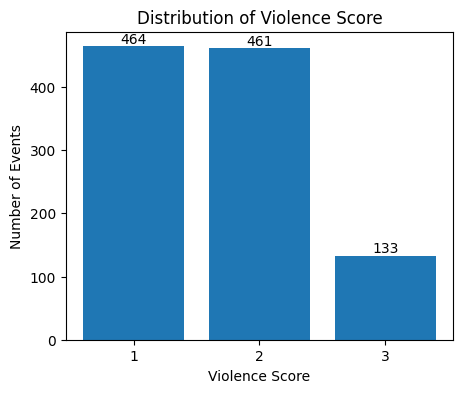

In [3]:
# Distribution of violence_score
violence_counts = (
    df["violence_score"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(5,4))
plt.bar(
    violence_counts.index.astype(str),
    violence_counts.values
)

plt.title("Distribution of Violence Score")
plt.xlabel("Violence Score")
plt.ylabel("Number of Events")

for i, count in enumerate(violence_counts.values):
    plt.text(i, count + 5, str(count), ha="center")

plt.show()

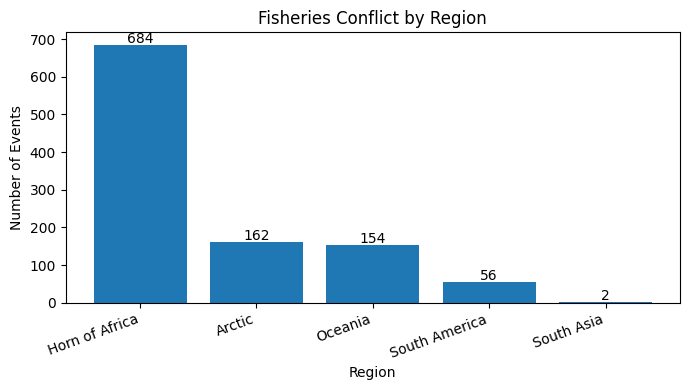

In [4]:
# Distribution of Regions
region_counts = df["region"].value_counts()

plt.figure(figsize=(7,4))
plt.bar(
    region_counts.index,
    region_counts.values
)

plt.title("Fisheries Conflict by Region")
plt.xlabel("Region")
plt.ylabel("Number of Events")
plt.xticks(rotation=20, ha="right")

for i, count in enumerate(region_counts.values):
    plt.text(i, count + 5, str(count), ha="center")

plt.tight_layout()
plt.show()

In [5]:
# Count of violence_score by region
pd.crosstab(df['region'], df['violence_score'])

violence_score,1,2,3
region,,,
Arctic,125,37,0
Horn of Africa,247,317,120
Oceania,84,61,9
South America,8,44,4
South Asia,0,2,0


## Obtain Sea Surface Temperature Variable
- From NOAA Dataset
- sst_diff_same_month_degC: the difference between the SST of that month and the historical same-calendar-month SST mean

In [6]:
sst_dir = "data/SST"
sst_file = os.path.join(sst_dir, "sst.mnmean.nc")

# A global monthly SST analysis from 1854-present derived from ICOADS data with missing data filled in by statistical methods
sst_download_url = (
    "https://downloads.psl.noaa.gov/Datasets/noaa.ersst.v5/sst.mnmean.nc"
)

os.makedirs(sst_dir, exist_ok=True)

if not os.path.exists(sst_file):
    print("Downloading NOAA ERSST v5 SST file...")
    
    response = requests.get(sst_download_url, stream=True)
    response.raise_for_status()
    
    with open(sst_file, "wb") as f:
        for chunk in response.iter_content(chunk_size=1024 * 1024):
            if chunk:
                f.write(chunk)
    
    print("Download complete:", sst_file)
else:
    print("SST file already exists:", sst_file)

Download complete: data/SST\sst.mnmean.nc


In [7]:
# open NOAA dataset
sst_ds = xr.open_dataset(sst_file, engine="netcdf4")

# inspect SST variable
sst_ds["sst"]

<xarray.DataArray 'sst' (time: 2070, lat: 89, lon: 180)> Size: 133MB
[33161400 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 17kB 1854-01-01 1854-02-01 ... 2026-06-01
  * lat      (lat) float32 356B 88.0 86.0 84.0 82.0 ... -82.0 -84.0 -86.0 -88.0
  * lon      (lon) float32 720B 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
Attributes:
    long_name:     Monthly Means of Sea Surface Temperature
    units:         degC
    var_desc:      Sea Surface Temperature
    level_desc:    Surface
    statistic:     Mean
    dataset:       NOAA Extended Reconstructed SST V5
    parent_stat:   Individual Values
    actual_range:  [-1.8     42.32636]
    valid_range:   [-1.8 45. ]

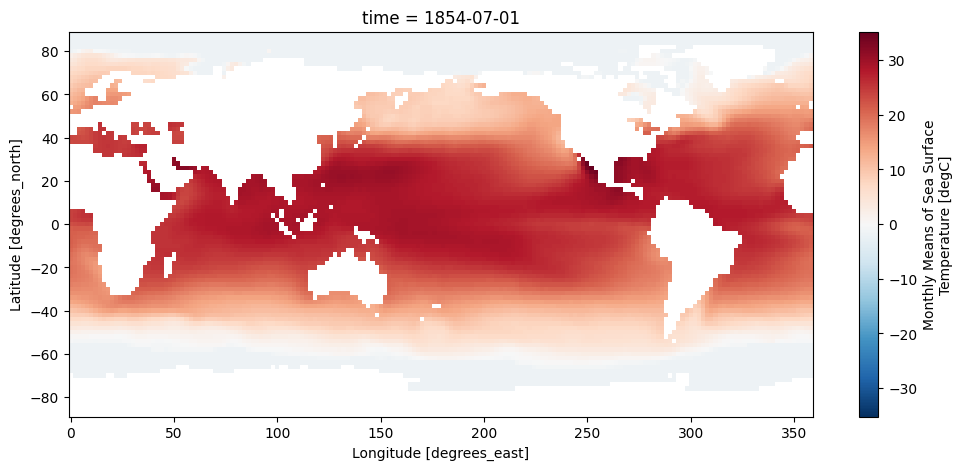

In [8]:
# check - look at one month's SST variable
sst_ds["sst"].isel(time=6).plot(figsize=(12,5))

In [9]:
# Add NOAA ERSST monthly SST to WWF event data
def haversine_km(lat1, lon1, lat2, lon2):
    lon1 = ((lon1 + 180) % 360) - 180
    lon2 = ((lon2 + 180) % 360) - 180

    R = 6371

    lat1, lon1, lat2, lon2 = map(
        np.radians,
        [lat1, lon1, lat2, lon2]
    )

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1)
        * np.cos(lat2)
        * np.sin(dlon / 2) ** 2
    )

    return 2 * R * np.arcsin(np.sqrt(a))


def add_sst_to_events(
    events_df,
    sst_ds,
    date_col="date",
    lat_col="latitude",
    lon_col="longitude",
    max_radius_deg=10
):

    df_sst = events_df.copy()

    df_sst[date_col] = pd.to_datetime(df_sst[date_col], errors="coerce")

    df_sst["sst_time"] = (
        df_sst[date_col]
        .dt.to_period("M")
        .dt.to_timestamp()
    )

    df_sst["lon_360"] = df_sst[lon_col] % 360

    lookup = (
        df_sst[["sst_time", lat_col, "lon_360"]]
        .dropna()
        .drop_duplicates()
        .reset_index(drop=True)
    )

    sst_subset = sst_ds.sel(
        time=slice(
            lookup["sst_time"].min(),
            lookup["sst_time"].max()
        )
    )

    def lookup_sst(row):
        event_time = row["sst_time"]
        event_lat = row[lat_col]
        event_lon = row["lon_360"]

        sst_month = sst_subset["sst"].sel(
            time=event_time,
            method="nearest"
        )

        for radius in range(0, max_radius_deg + 1, 2):

            lat_min = event_lat - radius
            lat_max = event_lat + radius
            lon_min = event_lon - radius
            lon_max = event_lon + radius

            lat_slice = slice(lat_max, lat_min)

            if lon_min < 0:
                candidate = xr.concat(
                    [
                        sst_month.sel(
                            lat=lat_slice,
                            lon=slice(lon_min % 360, 358)
                        ),
                        sst_month.sel(
                            lat=lat_slice,
                            lon=slice(0, lon_max)
                        )
                    ],
                    dim="lon"
                )

            elif lon_max > 358:
                candidate = xr.concat(
                    [
                        sst_month.sel(
                            lat=lat_slice,
                            lon=slice(lon_min, 358)
                        ),
                        sst_month.sel(
                            lat=lat_slice,
                            lon=slice(0, lon_max % 360)
                        )
                    ],
                    dim="lon"
                )

            else:
                candidate = sst_month.sel(
                    lat=lat_slice,
                    lon=slice(lon_min, lon_max)
                )

            valid = candidate.where(~np.isnan(candidate), drop=True)

            if valid.size > 0:
                valid_df = (
                    valid
                    .to_dataframe(name="sst_degC")
                    .reset_index()
                    .dropna(subset=["sst_degC"])
                )

                valid_df["sst_distance_km"] = valid_df.apply(
                    lambda x: haversine_km(
                        event_lat,
                        event_lon,
                        x["lat"],
                        x["lon"]
                    ),
                    axis=1
                )

                closest = valid_df.sort_values("sst_distance_km").iloc[0]

                return pd.Series({
                    "matched_sst_lat": closest["lat"],
                    "matched_sst_lon": closest["lon"],
                    "sst_degC": closest["sst_degC"],
                    "sst_search_radius_deg": radius,
                    "sst_distance_km": closest["sst_distance_km"]
                })

        return pd.Series({
            "matched_sst_lat": np.nan,
            "matched_sst_lon": np.nan,
            "sst_degC": np.nan,
            "sst_search_radius_deg": np.nan,
            "sst_distance_km": np.nan
        })

    sst_values = lookup.apply(lookup_sst, axis=1)

    lookup = pd.concat([lookup, sst_values], axis=1)

    df_sst = df_sst.merge(
        lookup,
        on=["sst_time", lat_col, "lon_360"],
        how="left"
    )

    return df_sst

In [10]:
# Adds historical same-calendar-month SST mean and difference.
    # For each event:
    # - Uses the matched NOAA ERSST grid cell.
    # - Uses only prior years for the same calendar month.
    # - Excludes the event month itself.

def add_sst_diff_same_month(
    events_df,
    sst_ds,
    date_col="date",
    matched_lat_col="matched_sst_lat",
    matched_lon_col="matched_sst_lon",
    sst_col="sst_degC"
):

    df_anom = events_df.copy()

    df_anom[date_col] = pd.to_datetime(df_anom[date_col], errors="coerce")

    df_anom["sst_time"] = (
        df_anom[date_col]
        .dt.to_period("M")
        .dt.to_timestamp()
    )

    df_anom["sst_month"] = df_anom["sst_time"].dt.month

    def historical_same_month_mean(row):
        if (
            pd.isna(row[matched_lat_col])
            or pd.isna(row[matched_lon_col])
            or pd.isna(row["sst_time"])
        ):
            return np.nan

        event_time = row["sst_time"]
        event_month = row["sst_month"]

        history = sst_ds["sst"].sel(
            lat=row[matched_lat_col],
            lon=row[matched_lon_col],
            method="nearest"
        )

        history = history.sel(
            time=history["time"] < event_time
        )

        history_same_month = history.sel(
            time=history["time"].dt.month == event_month
        )

        return float(history_same_month.mean().values)

    df_anom["sst_historical_same_month_mean_degC"] = df_anom.apply(
        historical_same_month_mean,
        axis=1
    )

    df_anom["sst_diff_same_month_degC"] = (
        df_anom[sst_col]
        - df_anom["sst_historical_same_month_mean_degC"]
    )

    return df_anom

In [11]:
# run the functions to add SST and find the SST difference from the month's historical average
df_with_sst_ocean = add_sst_to_events(
    events_df=df,
    sst_ds=sst_ds,
    date_col="date",
    lat_col="latitude",
    lon_col="longitude",
    max_radius_deg=10
)

df_with_sst_diff = add_sst_diff_same_month(
    events_df=df_with_sst_ocean,
    sst_ds=sst_ds,
    date_col="date"
)

In [12]:
# check - SST created variables
df_with_sst_diff[[
    "date",
    "sst_degC",
    "sst_historical_same_month_mean_degC",
    "sst_diff_same_month_degC"
]].head()

,date,sst_degC,sst_historical_same_month_mean_degC,sst_diff_same_month_degC
0,2011-12-01,28.764431,28.586988,0.177443
1,2011-10-12,26.528063,26.232477,0.295586
2,2011-08-01,29.538723,29.193617,0.345106
3,2011-11-10,29.095762,28.614426,0.481337
4,2011-10-13,28.260935,27.538280,0.722654


In [13]:
# check if there are any missing values
print("Count of records missing sst_degC: ", df_with_sst_diff["sst_degC"].isna().sum())
# df_with_sst_anom["sst_distance_km"].describe()


# Return rows with missing values
display(df_with_sst_diff[df_with_sst_diff["sst_degC"].isna()][
    ["date", "region", "country", "latitude", "longitude", "matched_sst_lat", "matched_sst_lon"]])

Count of records missing sst_degC:  3


,date,region,country,latitude,longitude,matched_sst_lat,matched_sst_lon
336,2011-04-11,Horn of Africa,Tanzania,-4.429992,29.791667,NaN,NaN
599,2014-11-15,Horn of Africa,Tanzania,-5.680850,29.708213,NaN,NaN
922,1995-09-01,Horn of Africa,Tanzania,-4.839290,29.670720,NaN,NaN


In [14]:
# drop WWF records with missing values
df_model = df_with_sst_diff.dropna(
    subset=["sst_diff_same_month_degC"]).copy()

# Confirm there are no missing values now
df_model["sst_degC"].isna().sum()

np.int64(0)

In [15]:
# check events where the matched ocean pixel is far away
df_model[df_model["sst_distance_km"] > 300]["country"].value_counts()

# # See rows
# df_model[df_model["sst_distance_km"] > 300][[
#     "date",
#     "region",
#     "country",
#     "latitude",
#     "longitude",
#     "matched_sst_lat",
#     "matched_sst_lon",
#     "sst_degC",
#     "sst_search_radius_deg",
#     "sst_distance_km"]]

country
Kenya       172
Tanzania     77
Russia        2
Name: count, dtype: int64

In [16]:
distance_summary = (
    df_model["sst_distance_km"]
    .describe())

display(distance_summary)

print()

display(
    df_model.loc[
        df_model["sst_distance_km"] > 300,
        "country"
    ].value_counts())

count    1055.000000
mean      250.121051
std       295.109350
min         4.674241
25%        73.729520
50%       106.397837
75%       183.617563
max      1060.150172
Name: sst_distance_km, dtype: float64

country
Kenya       172
Tanzania     77
Russia        2
Name: count, dtype: int64

In [17]:
# save df as a file
folder_path = "data/model"
file_name = "WWF_SST_combined.csv"
full_path = os.path.join(folder_path, file_name)
df_model.to_csv(full_path, index=False)

In [18]:
# create new df with points less than 300 km away
df_model_close = df_model[df_model["sst_distance_km"] <= 300].copy()

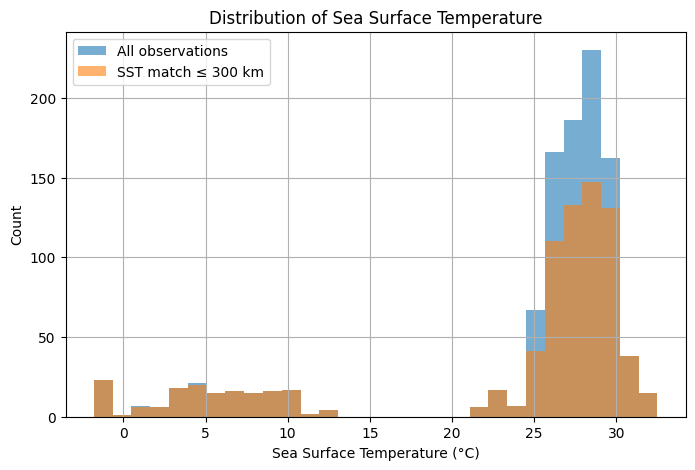

In [19]:
# distribution of SST
plt.figure(figsize=(8,5))

df_model["sst_degC"].hist(
    bins=30,
    alpha=0.6,
    label="All observations"
)

df_model_close["sst_degC"].hist(
    bins=30,
    alpha=0.6,
    label="SST match ≤ 300 km"
)

plt.xlabel("Sea Surface Temperature (°C)")
plt.ylabel("Count")
plt.title("Distribution of Sea Surface Temperature")
plt.legend()

plt.show()

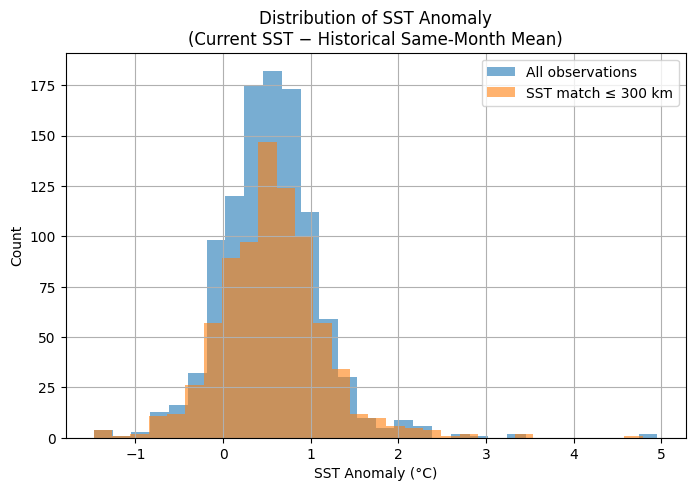

In [20]:
# inspect SST difference from historical SST
plt.figure(figsize=(8,5))

df_model["sst_diff_same_month_degC"].hist(
    bins=30,
    alpha=0.6,
    label="All observations"
)

df_model_close["sst_diff_same_month_degC"].hist(
    bins=30,
    alpha=0.6,
    label="SST match ≤ 300 km"
)

plt.xlabel("SST Anomaly (°C)")
plt.ylabel("Count")
plt.title("Distribution of SST Anomaly\n(Current SST − Historical Same-Month Mean)")
plt.legend()

plt.show()

## Add in Southern Oscillation index data
Source: https://www.climate.gov/news-features/understanding-climate/climate-variability-southern-oscillation-index

In [21]:
#Load dataset
soi_data = pd.read_csv('data/soi.txt', sep=r'\s+', header=0)

# make months a digit
soi_data = soi_data.melt(id_vars='YEAR', var_name = 'month', value_name='soi')
soi_data.columns = map(str.lower, soi_data.columns)
soi_data['month'] = pd.to_datetime(soi_data['month'], format= '%b').dt.month
soi_data

,year,month,soi
0,1951,1,1.5
1,1952,1,-0.9
2,1953,1,0.3
3,1954,1,0.7
4,1955,1,-0.5
...,...,...,...
907,2022,12,2.1
908,2023,12,-0.2
909,2024,12,1.2
910,2025,12,-0.0


In [22]:
# Merge datasets
df_model['month'] = pd.to_datetime(df_model['date']).dt.month
df3 = df_model.merge(soi_data, on=['year', 'month'], how = 'left')
df3

,source_file,event_id,date,year,country,region,Location,latitude,longitude,loc_accuracy,...,matched_sst_lat,matched_sst_lon,sst_degC,sst_search_radius_deg,sst_distance_km,sst_month,sst_historical_same_month_mean_degC,sst_diff_same_month_degC,month,soi
0,Oceania_No_AUS_NZL_Final,24328612817,2011-12-01,2011,American Samoa,Oceania,"Pago Pago, capital of American Samoa.",-14.27806,-170.70250,Town,...,-14.0,190.0,28.764431,2.0,81.815167,12,28.586988,0.177443,12,2.5
1,Oceania_No_AUS_NZL_Final,24359251958,2011-10-12,2011,French Polynesia,Oceania,"Port of Papeete, French Polynesia.",-17.53600,-149.58200,Town,...,-18.0,210.0,26.528063,2.0,67.978914,10,26.232477,0.295586,10,0.8
2,Oceania_No_AUS_NZL_Final,24349703891,2011-08-01,2011,Guam,Oceania,"Hotel Wharf, Port Authority of Guam.",13.46000,144.66500,Town,...,14.0,144.0,29.538723,2.0,93.622497,8,29.193617,0.345106,8,0.4
3,Oceania_No_AUS_NZL_Final,24327648295,2011-11-10,2011,Guam,Oceania,"Agana and Agat Marinas, Guam.",13.47567,144.74886,Town,...,14.0,144.0,29.095762,2.0,99.709164,11,28.614426,0.481337,11,1.1
4,Oceania_No_AUS_NZL_Final,24359264846,2011-10-13,2011,High Seas,Oceania,"Pacific high seas, near several Pacific island...",-14.47300,178.01800,International,...,-14.0,178.0,28.260935,2.0,52.630968,10,27.538280,0.722654,10,0.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1050,EcuadorFDE_10_19_23,ECU_e052,2020-12-20,2020,Ecuador,South America,Ecuador,-2.48900,-81.29000,NaN,...,-2.0,278.0,22.107147,2.0,95.811367,12,22.891109,-0.783962,12,1.8
1051,EcuadorFDE_10_19_23,ECU_e056,2020-12-21,2020,Ecuador,South America,Ecuador,-2.73100,-81.01100,NaN,...,-2.0,278.0,22.107147,2.0,136.674912,12,22.891109,-0.783962,12,1.8
1052,EcuadorFDE_10_19_23,ECU_e053,2021-11-19,2021,Ecuador,South America,"39 kilometers from Puerto Pizarro, near Santa ...",-3.15100,-80.50300,NaN,...,-2.0,280.0,22.337610,2.0,139.649963,11,22.897215,-0.559605,11,1.0
1053,EcuadorFDE_10_19_23,ECU_e054,2022-04-20,2022,Ecuador,South America,Santa Clara Island Marine Reserve,-3.16300,-80.43400,NaN,...,-2.0,280.0,23.835987,2.0,138.013305,4,24.238958,-0.402971,4,1.7


In [24]:
# data that only has close sst
df_model_close['month'] = pd.to_datetime(df_model['date']).dt.month
df4 = df_model_close.merge(soi_data, on=['year', 'month'], how = 'left')


pd.crosstab(df4['region'], df4['violence_score'])

violence_score,1,2,3
region,,,
Arctic,124,36,0
Horn of Africa,129,227,76
Oceania,84,61,9
South America,8,44,4
South Asia,0,2,0


In [ ]:
#Ensure there are no negative values
na_columns = df3.isna().sum()
na_columns[na_columns>0]

loc_accuracy                 218
IncrPressure                 156
ViolenceScore_Explanation    899
Summary                      681
Disputed                     218
ForcedLabor                  899
dtype: int64

## Data Analysis & Modeling

In [26]:
# Columns of interest for analysis
data = df4[[
    "region",
    "WeakGov", 
    "FishPop", 
    "EcoChngeOther", 
    "GroundsLim", 
    "ForeignFisher", 
    "IllegalFishing", 
    "IncrEfficiency", 
    "OpsScales",
    "Markets",
    "Poverty",
    "FoodInsecurity",
    "Marginalization",
    "StratLoc",
    "MaritimeCrime",
    "sst_diff_same_month_degC",
    'soi',
    "violence_score"
]]


In [27]:
# Filter by region
def regional_filtering(data, region_string = None):
    if region_string is None:
        filtered = data
    elif region_string not in data['region'].values:
        valid_regions = data['region'].unique().tolist()
        raise ValueError(f"{region_string} is not a valid region in the dataset. These are the available options: {valid_regions}.")
    else:
        filtered = data[data['region'] == region_string]
    return filtered

filtered = regional_filtering(data)

In [28]:
# Split data into training and testing groups
#Input: filtered data with 'region' variable from regional_filtering
def split_data(data):
    data2 = data.drop(columns = ['region'])
    X = data2.loc[:, data2.columns != 'violence_score']
    y = data2['violence_score']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = .2, stratify = y, random_state=42)
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = split_data(data)
X_test


,WeakGov,FishPop,EcoChngeOther,GroundsLim,ForeignFisher,IllegalFishing,IncrEfficiency,OpsScales,Markets,Poverty,FoodInsecurity,Marginalization,StratLoc,MaritimeCrime,sst_diff_same_month_degC,soi
741,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0.021139,0.4
585,1,0,0,1,1,1,0,0,0,0,0,0,0,1,1.509621,-1.5
489,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1.477745,-0.7
515,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0.189035,1.8
747,1,1,0,1,1,1,0,0,0,0,0,0,0,1,0.069511,0.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
323,0,1,0,0,1,0,1,0,0,0,0,0,0,0,0.672779,-0.4
294,0,1,0,1,0,0,1,0,0,0,0,0,0,0,1.262018,0.4
412,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1.023708,-0.1
670,0,0,0,1,1,1,0,0,0,0,0,0,0,0,0.685354,-1.4


In [38]:
def models(X_train, y_train):
    feature_names = X_train.columns 

    model_params = [
        {
            'name': 'Logistic Regression',
            'estimator': LogisticRegression(
                penalty='elasticnet',
                solver='saga',
                class_weight = 'balanced',
                random_state=42,
                max_iter = 6000
            ),
            'param_grid': {
                'l1_ratio': np.linspace(0, 1, 5),
                'C': np.linspace(.001, 10, 7) # smaller value = stronger regularization
            }
        },

        {
            'name': 'Random Forest',
            'estimator': RandomForestClassifier(class_weight = 'balanced', max_features= 8, random_state=42),
            'param_grid': {
                'n_estimators': np.linspace(20, 250, 25).astype(int),
                'max_depth': [4, 7],
                'min_samples_split': [3, 5]
            }
        }
    ]

    cv_strategy = StratifiedKFold(n_splits = 5, shuffle=True, random_state=42) 
    scoring = {
        'pr_auc': 'average_precision',
        'accuracy': 'accuracy'}

    results = []

    for item in model_params:
        grid = GridSearchCV(
            item['estimator'],
            item['param_grid'],
            cv=cv_strategy,
            scoring=scoring,
            refit = 'pr_auc',
            n_jobs = -1
        )

        grid.fit(X_train, y_train)

        model_name = item['name']

        
        for i, params in enumerate(grid.cv_results_['params']):

            # fit model for each parameter set
            temp_model = grid.estimator.set_params(**params)
            temp_model.fit(X_train, y_train)

            # feature selection per model
            if hasattr(temp_model, "coef_"): #for log reg
                coef = temp_model.coef_
                mask = np.any(np.abs(coef) > 1e-3, axis=0)

            elif hasattr(temp_model, "feature_importances_"): # for random forest
                importances = temp_model.feature_importances_
                mask = importances > 0

            else:
                mask = np.ones(len(feature_names), dtype=bool)

            selected_features = feature_names[mask]
            non_zero = np.sum(mask)

            results.append({
                'model': item['name'],
                'params': params,
                'training_data_accuracy': grid.cv_results_['mean_test_accuracy'][i],
                'pr_auc': grid.cv_results_['mean_test_pr_auc'][i],
                'non_zero_features': non_zero,
                'selected_features': list(selected_features),
                'mean_fit_time': grid.cv_results_['mean_fit_time'][i]
            })

    results_df = pd.DataFrame(results)

    # sort highest accuracy to lowest
    results_df = results_df.sort_values('training_data_accuracy', ascending=False).reset_index(drop=True)
    
    best_models = (
                    results_df
                    .sort_values('training_data_accuracy', ascending=False)
                    .groupby('model', as_index=False)
                    .first()
                    )

    return results_df, best_models

results_df, best_models = models(X_train, y_train)

In [44]:
best_models


,model,params,training_data_accuracy,pr_auc,non_zero_features,selected_features,mean_fit_time
0,Logistic Regression,"{'C': 1.6675, 'l1_ratio': 0.25}",0.600339,0.562177,16,"[WeakGov, FishPop, EcoChngeOther, GroundsLim, ...",0.033092
1,Random Forest,"{'max_depth': 7, 'min_samples_split': 5, 'n_es...",0.664038,0.623804,16,"[WeakGov, FishPop, EcoChngeOther, GroundsLim, ...",0.407068


In [54]:
# Assess performance with best models on test data
def assessment(best_models, X_train, y_train, X_test, y_test):
    #loop through each row of best_models
    for index, row in best_models.iterrows():
        model = row['model']
        params = row['params'] #dict

        # train model again with 'best' params and assess model on test data
        if model == 'Logistic Regression':
            model = LogisticRegression(**row['params'],
                                    penalty='elasticnet',
                                    solver='saga',
                                    class_weight = 'balanced',
                                    random_state=42,
                                    max_iter = 4000)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            # y_probability = pd.DataFrame(model.predict_proba(X_test), y_test) # compare violence_score to likelihood datapoint is each conflict type
        
            
            # Classification report
            display('Logistic Regression Results:')
            # print(classification_report(y_test, y_pred)) 
            

            #  df of intercept, coefs, and odds_ratio with variable names
            coef_df = pd.DataFrame(
                np.vstack([model.intercept_, model.coef_.T]),
                index=["Intercept"] + list(model.feature_names_in_),
                ).reset_index()
            coef_df.columns = ["Variable", "response_1_coef", "response_2_coef", "response_3_coef"]
            coef_df["odds_ratio_1"] = np.exp(coef_df["response_1_coef"])
            coef_df["odds_ratio_2"] = np.exp(coef_df["response_2_coef"])
            coef_df["odds_ratio_3"] = np.exp(coef_df["response_3_coef"])
            ordered_columns = [
                        "Variable",
                        "response_1_coef",
                        "odds_ratio_1",
                        "response_2_coef",
                        "odds_ratio_2",
                        "response_3_coef",
                        "odds_ratio_3",
                    ]
            coef_df = coef_df[ordered_columns]
            display(coef_df)


        if model == 'Random Forest':
            model = RandomForestClassifier(**row['params'], class_weight = 'balanced', max_features= 8, random_state=42)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

        
            display("Random Forest Results:")
            # # feature importance
            # importances = model.feature_importances_
            # feature_names = model.feature_names_in_
            # feature_imp_df = pd.DataFrame({'Feature': feature_names, 
            #                                'Gini Importance': importances
            #                                }).sort_values('Gini Importance', ascending=False)
            # display(feature_imp_df)

            # plt.figure()
            # plt.barh(feature_imp_df['Feature'], feature_imp_df['Gini Importance'])
            # plt.xlabel('Gini Importance')
            # plt.title('Feature Importance - Gini Importance')
            # plt.gca().invert_yaxis() # feature with largest importance on top
            # plt.show()

            # Permutation Importance
            feature_names = model.feature_names_in_
            perm = permutation_importance(
                model,
                X_test,
                y_test,
                n_repeats=20,
                random_state=42,
                scoring="average_precision"
            )

            perm_df = pd.DataFrame({
                "Feature": feature_names,
                "Permutation Importance": perm.importances_mean,
                "Std": perm.importances_std
            }).sort_values(
                "Permutation Importance",
                ascending=False
            )

            display(perm_df)

            plt.figure(figsize=(8,5))
            plt.barh(
                perm_df["Feature"],
                perm_df["Permutation Importance"],
                xerr=perm_df["Std"]
            )
            plt.xlabel("Decrease in Average Precision")
            plt.title("Permutation Feature Importance")
            plt.gca().invert_yaxis()
            plt.show()

            #Shapley additive explanations
            explainer = shap.TreeExplainer(model)
            shap_values = explainer.shap_values(X_test)

            colors = ListedColormap(["#0A2540", "#4A90E2", "#A5C7E6"])
            shap.summary_plot(shap_values, 
                              X_test, 
                              plot_type="bar", 
                              color = colors, 
                              feature_names = feature_names,
                              class_names = ['low-intensity', 'medium-intensity', 'high-intensity'], 
                              show = False)
            plt.title("Feature Importance - SHAP")
            plt.xlabel("Mean Absolute SHAP Value (Impact on Model Output)")
            plt.ylabel("Features")
        

        # Classification report
        print(classification_report(y_test, y_pred)) 

        # Confusion matrix 
        cm = confusion_matrix(y_test, y_pred, labels=[1, 2, 3])
        plt.figure()
        disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = [1, 2, 3])
        disp.plot(cmap = plt.cm.Blues)
        plt.title(f"Confusion Matrix: {row['model']}")
        plt.xlabel('Prediction')
        plt.ylabel('Actual')
        plt.show()

   

'Logistic Regression Results:'

,Variable,response_1_coef,odds_ratio_1,response_2_coef,odds_ratio_2,response_3_coef,odds_ratio_3
0,Intercept,0.687406,1.988551,1.060474,2.887739,-1.747880,0.174143
1,WeakGov,0.500030,1.648770,-0.702258,0.495466,0.202228,1.224127
2,FishPop,0.438429,1.550270,0.256313,1.292157,-0.694742,0.499203
3,EcoChngeOther,1.679116,5.360813,-0.744266,0.475083,-0.934850,0.392645
4,GroundsLim,0.373133,1.452278,-0.479043,0.619376,0.105910,1.111721
5,ForeignFisher,-0.462292,0.629839,0.273934,1.315128,0.188358,1.207266
6,IllegalFishing,-0.319164,0.726756,0.402221,1.495141,-0.083057,0.920299
7,IncrEfficiency,0.327353,1.387291,-0.310665,0.732959,-0.016688,0.983451
8,OpsScales,0.570987,1.770012,-0.147233,0.863093,-0.423754,0.654585
9,Markets,2.194859,8.978737,-1.213706,0.297094,-0.981153,0.374879


              precision    recall  f1-score   support

           1       0.61      0.42      0.50        26
           2       0.76      0.57      0.65        46
           3       0.26      0.60      0.36        15

    accuracy                           0.53        87
   macro avg       0.54      0.53      0.50        87
weighted avg       0.63      0.53      0.56        87



<Figure size 640x480 with 0 Axes>

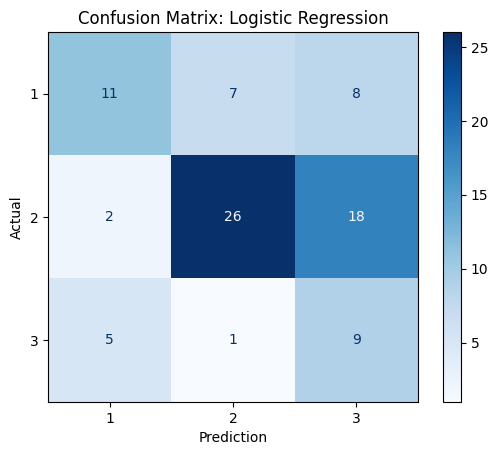

'Random Forest Results:'

,Feature,Permutation Importance,Std
2,EcoChngeOther,0.055813,0.029198
12,StratLoc,0.048323,0.014940
0,WeakGov,0.048236,0.026999
13,MaritimeCrime,0.036035,0.012537
4,ForeignFisher,0.020694,0.016392
1,FishPop,0.012936,0.012447
3,GroundsLim,0.003840,0.006373
9,Poverty,0.000787,0.005191
8,Markets,0.000000,0.000000
11,Marginalization,-0.000442,0.011952


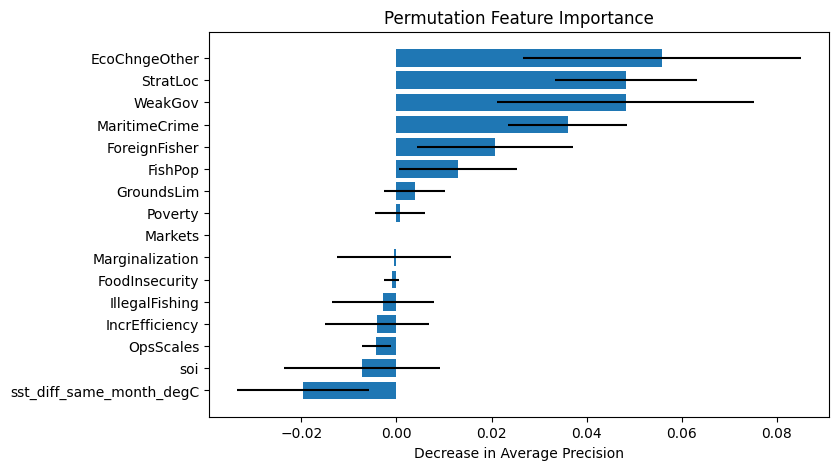

              precision    recall  f1-score   support

           1       0.56      0.35      0.43        26
           2       0.67      0.70      0.68        46
           3       0.22      0.33      0.26        15

    accuracy                           0.53        87
   macro avg       0.48      0.46      0.46        87
weighted avg       0.56      0.53      0.53        87



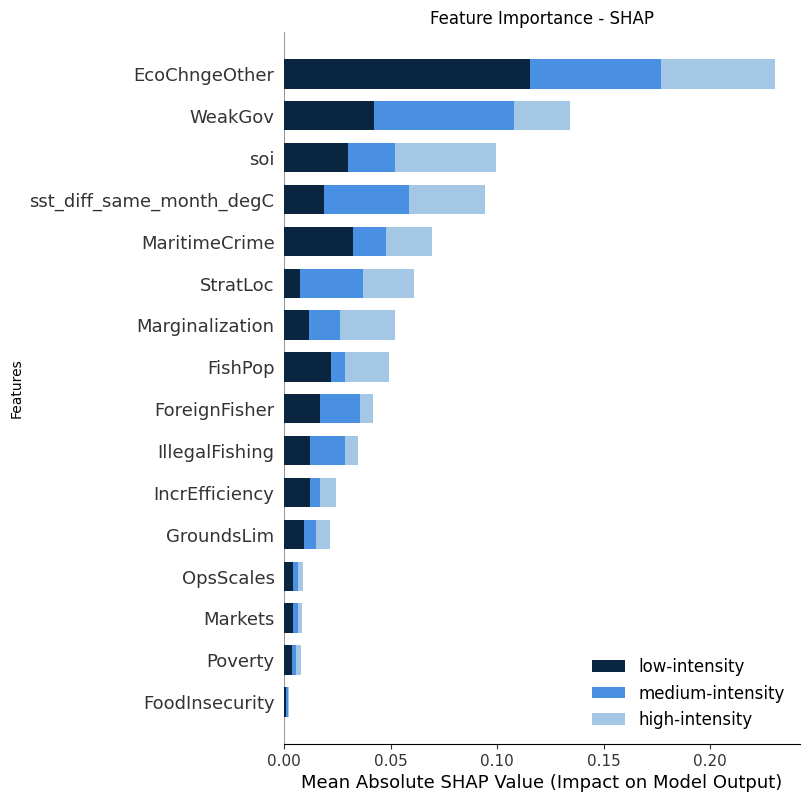

<Figure size 640x480 with 0 Axes>

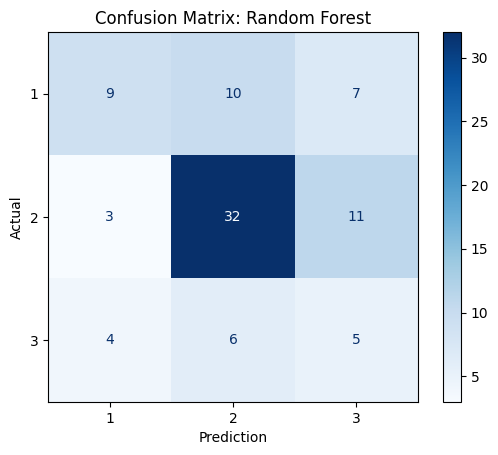

In [55]:
# Run all analysis
def analysis(data, region = None):
    filtered_data = regional_filtering(data, region)
    X_train, X_test, y_train, y_test = split_data(filtered_data)
    scaler = MinMaxScaler()
    continuous_cols = ["sst_diff_same_month_degC", 'soi']
    X_train_scaled_df = X_train.copy()
    X_test_scaled_df = X_test.copy()
    X_train_scaled_df[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
    X_test_scaled_df[continuous_cols] = scaler.transform(X_test[continuous_cols])

    results_df, best_models = models(X_train_scaled_df, y_train)
    assessment(best_models, X_train_scaled_df, y_train, X_test_scaled_df, y_test)

analysis(data, "Horn of Africa")

## Forward selection

In [ ]:
# RF forward selection: https://www.youtube.com/watch?v=POCvLGRLDzM

## References
- Creating a correlation matrix: https://www.geeksforgeeks.org/data-science/create-a-correlation-matrix-using-python/
- different solvers explanation: https://stackoverflow.com/questions/38640109/logistic-regression-python-solvers-definitions
- Logistic regression: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
- Confusion Matrix chart: https://www.geeksforgeeks.org/machine-learning/confusion-matrix-machine-learning/
- Feature Importance chart: https://www.geeksforgeeks.org/machine-learning/feature-importance-with-random-forests/
- NOAA Extended Reconstructed SST V5: https://psl.noaa.gov/data/gridded/data.noaa.ersst.v5.html